Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6157.91it/s]


Original sentence: The movie was not good
P(POSITIVE): 0.0002

     The | movie was not good        | P(POSITIVE)=0.0003 | I=-0.0000
   movie | The was not good          | P(POSITIVE)=0.0002 | I=-0.0000
     was | The movie not good        | P(POSITIVE)=0.0002 | I=-0.0000
     not | The movie was good        | P(POSITIVE)=0.9999 | I=-0.9996
    good | The movie was not         | P(POSITIVE)=0.0023 | I=-0.0020


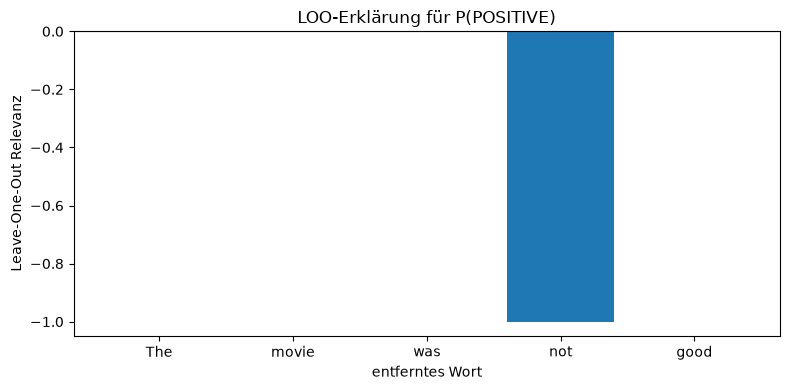

In [4]:
from transformers import pipeline
import matplotlib.pyplot as plt

# Sentimentanalyse Modell
classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

# Wahrscheinlichkeit für die Klasse POSITIVE zurückgeben
def positive_score(text):
    result = classifier(text, top_k=None)

    scores = {
        item["label"]: item["score"]
        for item in result
    }

    return scores["POSITIVE"]

# Beispielsatz
sentence = "The movie was not good"

words = sentence.split()

base_score = positive_score(sentence)

print("Original sentence:", sentence)
print("P(POSITIVE):", round(base_score, 4))
print()

# Leave-One-Out:

importances = []

for i, word in enumerate(words):

    modified_words = words[:i] + words[i+1:]
    modified_sentence = " ".join(modified_words)

    new_score = positive_score(modified_sentence)

    importance = base_score - new_score

    importances.append(importance)

    print(
        f"{word:>8s} | "
        f"{modified_sentence:<25s} | "
        f"P(POSITIVE)={new_score:.4f} | "
        f"I={importance:+.4f}"
    )

# Visualisierung

plt.figure(figsize=(8, 4))
plt.bar(words, importances)
plt.axhline(0)
plt.ylabel("Leave-One-Out Relevanz")
plt.xlabel("entferntes Wort")
plt.title("LOO-Erklärung für P(POSITIVE)")
plt.tight_layout()
plt.show()
